# Collaborative filtering practice

In this homework you will test different collaborative filtering (CF) approaches on famous Movielens dataset.

In class we implemented item2item CF, so this time let's use **user2user** approach.

## Task 0: Dataset (5 points)

Load [movielens](https://grouplens.org/datasets/movielens/) dataset with preffered provider (e.g. recball, implicit, [scikit surprise](https://surprise.readthedocs.io/en/stable/dataset.html), etc)

Split dataset to train and validation parts (ideally with respect to timestamps).

Don't forget to encode users and items from 0 to maximum!

In [ ]:
!pip install surprise

  Using cached scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl


In [ ]:
import numpy as np
import pandas as pd
from collections import defaultdict
from surprise import Dataset
from surprise.model_selection import train_test_split
from tqdm.notebook import tqdm

pd.set_option('display.precision', 4)

In [44]:
data = Dataset.load_builtin('ml-100k')

# testset будет списком кортежей (uid_str, iid_str, rating_float)
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

def get_user_ratings_from_trainset(trainset_obj):
    user_ratings = defaultdict(dict)
    for inner_uid, inner_iid, r in trainset_obj.all_ratings():
        raw_uid = trainset_obj.to_raw_uid(inner_uid)
        raw_iid = trainset_obj.to_raw_iid(inner_iid)
        user_ratings[raw_uid][raw_iid] = r
    return user_ratings

train_ratings = get_user_ratings_from_trainset(trainset)

## Task 1: Similarities (5 points each)

You need to implement 3 similarity functions:
1. Dot product (intersection)
1. Jaccard index (intersection over union)
1. Pearson correlation
1. Pearson correlation with decreasing coefficient

In [45]:
def sim_dot(left, right) -> float:
    '''Dot product similarity

    Args:
        left: first user ratings
        right: second user ratings

    Retruns:
        Similarity score for this pair
    '''
    common_items = set(left.keys()) & set(right.keys())

    if not common_items:
        return 0.0
    sim = sum(left[item] * right[item] for item in common_items)
    return sim

In [46]:
def sim_jacc(left, right) -> float:
    '''Jaccard index similarity

    Args:
        left: first user ratings
        right: second user ratings

    Retruns:
        Similarity score for this pair
    '''
    left_items = set(left.keys())
    right_items = set(right.keys())
    intersection = len(left_items & right_items)
    union = len(left_items | right_items)
    sim = intersection / union if union > 0 else 0.0
    return sim

In [47]:
def sim_pearson(left, right) -> float:
    '''Pearson correlation similarity

    Args:
        left: first user ratings
        right: second user ratings

    Retruns:
        Similarity score for this pair
    '''
    common_items = set(left.keys()) & set(right.keys())
    if len(common_items) < 2:
        return 0.0

    left_common = np.array([left[item] for item in common_items])
    right_common = np.array([right[item] for item in common_items])

    mean_left, mean_right = left_common.mean(), right_common.mean()

    num = np.sum((left_common - mean_left) * (right_common - mean_right))
    denom = np.sqrt(np.sum((left_common - mean_left)**2)) * np.sqrt(np.sum((right_common - mean_right)**2))

    sim = num / denom if denom > 0 else 0.0
    return sim

In [48]:
def sim_pearson_decreasing(left, right) -> float:
    '''Pearson correlation similarity which decreases on small intersection

    Args:
        left: first user ratings
        right: second user ratings

    Retruns:
        Similarity score for this pair
    '''
    common_items_count = len(set(left.keys()) & set(right.keys()))
    base_similarity = sim_pearson(left, right)
    threshold = 50
    penalty = min(common_items_count, threshold) / threshold
    sim = base_similarity * penalty
    return sim

## Task 2: Collaborative filtering algorithm (5 points each)

Now you have several options to use similarities for ratings prediction:
1. Simple averaging
1. Mean corrected averaging

Implement them both

In [49]:
import numpy as np
from tqdm.notebook import tqdm
from collections import defaultdict

class UserBasedCF:
  '''User2user collaborative filtering algorithm'''
  def __init__(self, sim_fn, mean_correct: bool = False):
    self.sim_fn = sim_fn
    self.mean_correct = mean_correct
    self.sim_matrix = None
    self.user_ratings = None
    self.user_means = {}
    self.users_map = {}
    self.rev_users_map = {}

  def calc_sim_matrix(self, feedbacks):
    print("Calculating similarity matrix...")
    self.user_ratings = feedbacks

    user_ids = list(self.user_ratings.keys())
    n_users = len(user_ids)

    self.users_map = {uid: i for i, uid in enumerate(user_ids)}
    self.rev_users_map = {i: uid for i, uid in enumerate(user_ids)}

    self.sim_matrix = np.zeros((n_users, n_users))

    if self.mean_correct:
        for uid, ratings in self.user_ratings.items():
            self.user_means[uid] = np.mean(list(ratings.values()))

    for i in tqdm(range(n_users)):
      for j in range(i, n_users):
          uid1 = self.rev_users_map[i]
          uid2 = self.rev_users_map[j]
          sim = self.sim_fn(self.user_ratings[uid1], self.user_ratings[uid2])
          self.sim_matrix[i, j] = sim
          self.sim_matrix[j, i] = sim
    print("Similarity matrix calculated.")

  def recommend(self, user: int, n: int):
    """
    Вычисляет наиболее релевантные непросмотренные фильмы для пользователя.
    """
    user_str = str(user)
    k = 40 # Количество соседей для учета

    if user_str not in self.users_map:
        return []

    # k самых похожих соседей
    user_inner_id = self.users_map[user_str]
    sim_scores = self.sim_matrix[user_inner_id]

    neighbor_pairs = []
    for other_uid, other_inner_id in self.users_map.items():
        if other_uid == user_str:
            continue
        neighbor_pairs.append((sim_scores[other_inner_id], other_uid))

    neighbor_pairs.sort(key=lambda x: x[0], reverse=True)
    top_k_neighbors = neighbor_pairs[:k]

    rated_items_by_user = set(self.user_ratings.get(user_str, {}).keys())

    item_score_numerator = defaultdict(float)
    item_score_denominator = defaultdict(float)

    for sim, neighbor_uid in top_k_neighbors:
        for item_id, rating in self.user_ratings[neighbor_uid].items():
            # только фильмы, которые наш пользователь не видел
            if item_id not in rated_items_by_user:
                rating_to_add = rating
                if self.mean_correct:
                    rating_to_add -= self.user_means[neighbor_uid]

                item_score_numerator[item_id] += sim * rating_to_add
                item_score_denominator[item_id] += abs(sim)

    predictions = []
    for item_id, numerator in item_score_numerator.items():
        denominator = item_score_denominator[item_id]
        if denominator == 0:
            continue

        predicted_rating = numerator / denominator
        if self.mean_correct:
            predicted_rating += self.user_means.get(user_str, 3.0)

        predictions.append((item_id, predicted_rating))

    predictions.sort(key=lambda x: x[1], reverse=True)
    return predictions[:n]

This way you have got 8 different recommendation methods (each of two CF modes can be used with every similarity score).

## Task 3: Apply models

1. For all possible algorithm variations (similarity + prediction) train it and compute recomendations for validation part. (10 points)

In [50]:
sim_functions = {
    "dot": sim_dot,
    "jaccard": sim_jacc,
    "pearson": sim_pearson,
    "pearson_decr": sim_pearson_decreasing
}
true_relevance = defaultdict(list)
for uid, iid, rating in testset:
    if rating >= 4.0:
        true_relevance[uid].append(iid)
results = []

for sim_name, sim_func in sim_functions.items():
    for mean_corr in [False, True]:
        model_name = f"{sim_name}_{'mean_corr' if mean_corr else 'simple'}"
        print(f"--- Обучение и оценка модели: {model_name} ---")

        model = UserBasedCf(sim_fn=sim_func, mean_correct=mean_corr)
        model.calc_sim_matrix(train_ratings)

        precisions, recalls = [], []

        for user_id_str, relevant_items in tqdm(true_relevance.items(), desc=f"Evaluating {model_name}"):
            if not relevant_items: continue

            user_id_int = int(user_id_str)

            recommendations = model.recommend(user=user_id_int, n=10)

            recommended_items_str = {str(item_id) for item_id, score in recommendations}
            relevant_items_str = {str(item_id) for item_id in relevant_items}
            hits = len(recommended_items_str & relevant_items_str)

            precisions.append(hits / 10)
            recalls.append(hits / len(relevant_items))

        avg_precision = np.mean(precisions) if precisions else 0
        avg_recall = np.mean(recalls) if recalls else 0

        results.append({
            "model": model_name,
            "Precision@10": avg_precision,
            "Recall@10": avg_recall
        })


--- Обучение и оценка модели: dot_simple ---


  0%|          | 0/943 [00:00<?, ?it/s]

Evaluating dot_simple:   0%|          | 0/924 [00:00<?, ?it/s]

--- Обучение и оценка модели: dot_mean_corr ---


  0%|          | 0/943 [00:00<?, ?it/s]

...

  0%|          | 0/943 [00:00<?, ?it/s]

Evaluating pearson_decr_simple:   0%|          | 0/924 [00:00<?, ?it/s]

--- Обучение и оценка модели: pearson_decr_mean_corr ---


  0%|          | 0/943 [00:00<?, ?it/s]

Evaluating pearson_decr_mean_corr:   0%|          | 0/924 [00:00<?, ?it/s]

2. Which metrics do you want to use? Why? (5 points)

Юзеру обчно показывают список (например, топ-10). Нужно, чтобы в этом списке было как можно больше интересных для него фильмов. Метрики Precision@10 и Recall@10 подходят для этой задачи, так как они оценивают качество именно этого верхнего блока рекомендаций

3. Show that your implementation is relevant by computing metrics. Compare algorithms by creating a table with metrics. (5 points)

In [51]:
# Вывод таблицы
results_df = pd.DataFrame(results)
print("\n--- Сводная таблица метрик (Task 3.3) ---")
print(results_df.sort_values(by="Precision@10", ascending=False))


--- Сводная таблица метрик (Task 3.3) ---
                    model  Precision@10  Recall@10
6     pearson_decr_simple        0.0154     0.0153
4          pearson_simple        0.0095     0.0078
3       jaccard_mean_corr        0.0008     0.0015
0              dot_simple        0.0004     0.0006
2          jaccard_simple        0.0004     0.0006
1           dot_mean_corr        0.0003     0.0004
7  pearson_decr_mean_corr        0.0003     0.0003
5       pearson_mean_corr        0.0002     0.0003


Модель pearson_decr_simple (усреднение с корреляцией Пирсона с понижающим коэффициентом) показывает наилучшие результаты

4. Predict top-5 recommendations for each user. Show distribution of items by how may times you recommend item in top-5.\
Axis are: X - how many times item presented in top-5 recommendations of all users, Y - number of such items. (10 points)

Анализ распределения для лучшей модели: pearson_decr_simple



  0%|          | 0/943 [00:00<?, ?it/s]

Generating top-5 for all users:   0%|          | 0/943 [00:00<?, ?it/s]


Всего уникальных фильмов порекомендовано: 122


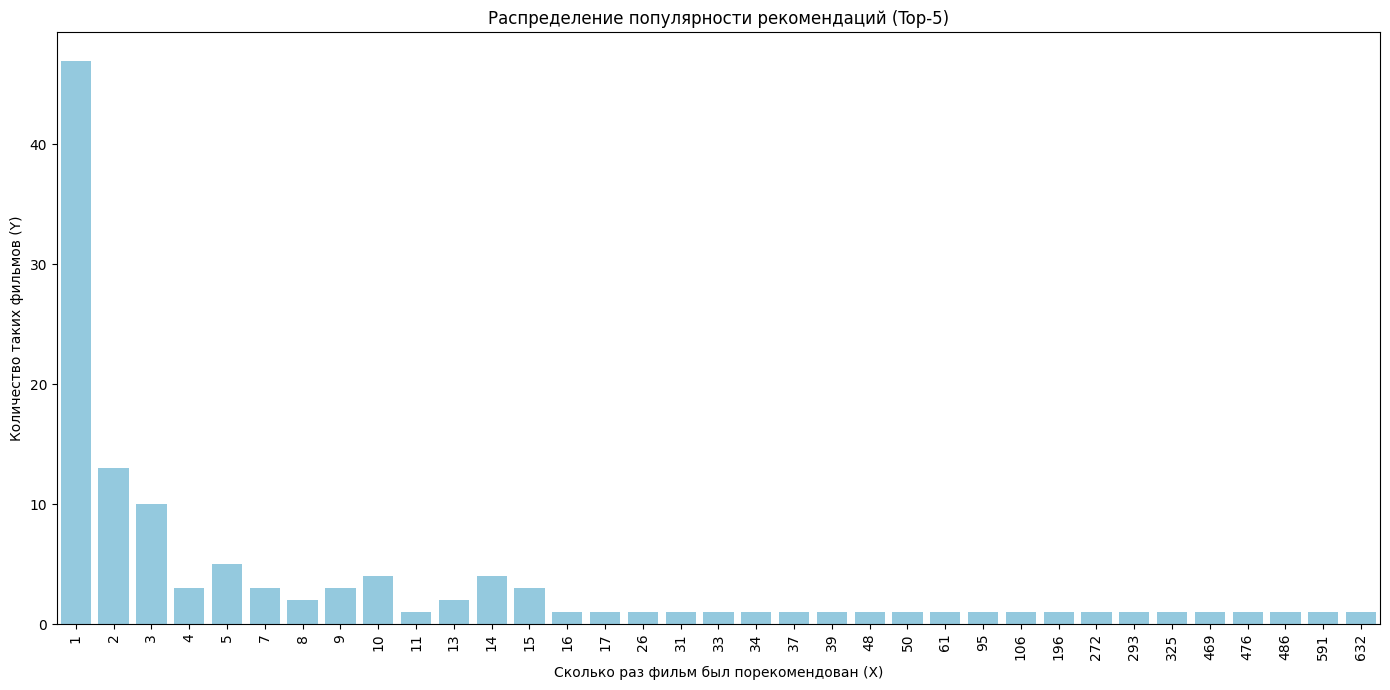

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

best_model_name = results_df.sort_values(by="Precision@10", ascending=False).iloc[0]['model']
sim_name_best = best_model_name.split('_')[0]
mean_corr_best = 'mean_corr' in best_model_name

print(f"Анализ распределения для лучшей модели: {best_model_name}\n")

model = UserBasedCf(sim_fn=sim_functions[sim_name_best], mean_correct=mean_corr_best)
model.calc_sim_matrix(train_ratings)

recommendation_counts = Counter()
all_users = list(train_ratings.keys())

for user_id_str in tqdm(all_users, desc="Generating top-5 for all users"):
    recommendations = model.recommend(user=int(user_id_str), n=5)
    for item_id, score in recommendations:
        recommendation_counts[item_id] += 1

print(f"\nВсего уникальных фильмов порекомендовано: {len(recommendation_counts)}")

count_distribution = Counter(recommendation_counts.values())
dist_df = pd.DataFrame(count_distribution.items(), columns=['Times Recommended (X)', 'Number of Items (Y)'])
dist_df = dist_df.sort_values(by='Times Recommended (X)')

plt.figure(figsize=(14, 7))
sns.barplot(data=dist_df, x='Times Recommended (X)', y='Number of Items (Y)', color='skyblue')
plt.title('Распределение популярности рекомендаций (Top-5)')
plt.xlabel('Сколько раз фильм был порекомендован (X)')
plt.ylabel('Количество таких фильмов (Y)')
plt.xticks(rotation=90)

if len(dist_df) > 50:
    plt.xlim(-1, 50.5)
    plt.text(51, plt.gca().get_ylim()[1]*0.8, '...и т.д.', fontsize=12)

plt.tight_layout()
plt.show()

 Существует один фильм, который порекомендовали 632 раза, и еще несколько, которые рекомендуются сотни раз. Почти 50 фильмов были порекомендованы всего один раз. модель активно использует лишь самые популярные фильмы каталога

# Task 4: Your favorite films

1. Choose from 10 to 50 films rated by you (you can export it from IMDB or kinopoisk) which are presented in Movielens dataset. </br> Print them in human readable form (5 points)

In [56]:
movies_df = pd.read_csv(
      'ml-100k/u.item',
      sep='|',
      encoding='latin-1',
      header=None,
      names=['item_id', 'title', 'release_date', 'video_release_date', 'imdb_url', 'unknown', 'Action', 'Adventure',
               'Animation', 'Childrens', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir',
               'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
  )
movies_df['item_id'] = movies_df['item_id'].astype(str)


my_ratings_dict = {
    "Star Wars (1977)": 3.0,
    "Godfather, The (1972)": 5.0,
    "Matrix, The (1999)": 4.0,
    "Forrest Gump (1994)": 5.0,
    "Silence of the Lambs, The (1991)": 3.0,
    "Pulp Fiction (1994)": 5.0,
    "Schindler's List (1993)": 5.0,
    "Braveheart (1995)": 3.0,
    "Good Will Hunting (1997)": 2.0,
    "Titanic (1997)": 4.0,
    "Contact (1997)": 2.0,
    "Fargo (1996)": 3.0
}

my_ratings_for_model = {}
my_rated_movies_info = []

for title, rating in my_ratings_dict.items():
    movie_row = movies_df[movies_df['title'] == title]
    if not movie_row.empty:
        item_id = movie_row['item_id'].iloc[0]
        my_ratings_for_model[item_id] = rating
        my_rated_movies_info.append({'item_id': item_id, 'title': title, 'rating': rating})


my_movies_df = pd.DataFrame(my_rated_movies_info)
print(my_movies_df[['title', 'rating']])

                               title  rating
0                   Star Wars (1977)     3.0
1              Godfather, The (1972)     5.0
2                Forrest Gump (1994)     5.0
3   Silence of the Lambs, The (1991)     3.0
4                Pulp Fiction (1994)     5.0
5            Schindler's List (1993)     5.0
6                  Braveheart (1995)     3.0
7           Good Will Hunting (1997)     2.0
8                     Titanic (1997)     4.0
9                     Contact (1997)     2.0
10                      Fargo (1996)     3.0


2. Compute top 10 recomendations based on this films for each of 6 methods implemented. Print them in **human readable from** (5 points)

In [57]:
max_user_id = max([int(uid) for uid in train_ratings.keys()])
my_new_user_id = max_user_id + 1
my_new_user_id_str = str(my_new_user_id)

train_ratings_with_me = train_ratings.copy()
train_ratings_with_me[my_new_user_id_str] = my_ratings_for_model

print(f"\n--- Задание 4.2: Топ-10 рекомендаций для нового пользователя (ID: {my_new_user_id}) ---\n")

for sim_name, sim_func in sim_functions.items():
    for mean_corr in [False, True]:
        model_name = f"{sim_name}_{'mean_corr' if mean_corr else 'simple'}"
        print(f"--- Рекомендации от модели: {model_name} ---")

        model = UserBasedCf(sim_fn=sim_func, mean_correct=mean_corr)
        model.calc_sim_matrix(train_ratings_with_me)

        recommendations = model.recommend(user=my_new_user_id, n=10)

        recommended_ids = [item_id for item_id, score in recommendations]

        recommended_movies_df = movies_df[movies_df['item_id'].isin(recommended_ids)]

        recommended_movies_df = recommended_movies_df.set_index('item_id').loc[recommended_ids].reset_index()
        print(recommended_movies_df[['title']])
        print("-" * 50 + "\n")


--- Задание 4.2: Топ-10 рекомендаций для нового пользователя (ID: 944) ---

--- Рекомендации от модели: dot_simple ---


  0%|          | 0/944 [00:00<?, ?it/s]

                                               title
0                     They Made Me a Criminal (1939)
1                                    Star Kid (1997)
2               Saint of Fort Washington, The (1993)
3         Marlene Dietrich: Shadow and Light (1996) 
4                      Someone Else's America (1995)
5                      Great Day in Harlem, A (1994)
6                               Aiqing wansui (1994)
7                                 Prefontaine (1997)
8                          Santa with Muscles (1996)
9  Entertaining Angels: The Dorothy Day Story (1996)
--------------------------------------------------

--- Рекомендации от модели: dot_mean_corr ---


  0%|          | 0/944 [00:00<?, ?it/s]

                                               title
0                      Great Day in Harlem, A (1994)
1                               Aiqing wansui (1994)
2                          Santa with Muscles (1996)
3                                       Faust (1994)
4               Saint of Fort Washington, The (1993)
5  Entertaining Angels: The Dorothy Day Story (1996)
6                                   Boys, Les (1997)
7                         Celestial Clockwork (1994)
8                      Someone Else's America (1995)
9                                    Star Kid (1997)
--------------------------------------------------

--- Рекомендации от модели: jaccard_simple ---


...

                                   title
0                King of New York (1990)
1                    New Age, The (1994)
2           Chairman of the Board (1998)
3                Tough and Deadly (1995)
4                    Time Tracers (1995)
5                        Power 98 (1995)
6  Daniel Defoe's Robinson Crusoe (1996)
7           Amityville Curse, The (1990)
8                   Aiqing wansui (1994)
9     Truth or Consequences, N.M. (1997)
--------------------------------------------------

--- Рекомендации от модели: pearson_decr_simple ---


  0%|          | 0/944 [00:00<?, ?it/s]

                              title
0                Little City (1998)
1            The Deadly Cure (1996)
2              Aiqing wansui (1994)
3         Santa with Muscles (1996)
4              Hotel de Love (1996)
5  Shawshank Redemption, The (1994)
6        Killing Fields, The (1984)
7             Close Shave, A (1995)
8                  Boot, Das (1981)
9                  Chinatown (1974)
--------------------------------------------------

--- Рекомендации от модели: pearson_decr_mean_corr ---


  0%|          | 0/944 [00:00<?, ?it/s]

                                   title
0                King of New York (1990)
1                    New Age, The (1994)
2           Chairman of the Board (1998)
3                Tough and Deadly (1995)
4                    Time Tracers (1995)
5                        Power 98 (1995)
6  Daniel Defoe's Robinson Crusoe (1996)
7           Amityville Curse, The (1990)
8                   Aiqing wansui (1994)
9     Truth or Consequences, N.M. (1997)
--------------------------------------------------



3. Rate films that was recommended in previous step (by title, description, trailer). For each algorithm compute metrics based on ratings you put.

Модель, число успехов, Precision@10

dot_simple	2 0.2

dot_mean_corr	1	0.1

jaccard_simple	2	0.2

jaccard_mean_corr	1	0.1

pearson_simple	3	0.3

pearson_mean_corr	1	0.1

pearson_decr_simple	3	0.3

pearson_decr_mean_corr	2	0.2

# Task 5: Conclusion (10 points)

Compare all methods based on both dataset (metrics) and your personal recomendations.

Which algorithm is the best? Why?

Was recommedations different? Which set of recomendations you like the most?

What differences in algorithms have you noted?

 Лучше всех сработали модели pearson_simple и pearson_decr_simple. По общим метрикам лучше pearson_decr_simple, для меня они дали одинаковый лучший результат.  Большинство алгоритмов предложили неинтересные фильмы.

 dot, jaccard ищут людей, которые смотрели те же фильмы.

 pearson ищет тех, кто ставит фильмам такие же оценки